# Regresion — Prediccion de temperatura exacta (C)
Modelos: Ridge Lineal, Ridge Polinomica, Random Forest, Gradient Boosting, SVR

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

CSV_PATH  = Path("dataset_features_temperatura.csv")
FEAT_JSON = Path("features_seleccionadas.json")

In [3]:
df = pd.read_csv(CSV_PATH)

META_COLS = {
    "sample_uid", "sample_id", "tx_path", "rx_path",
    "tx_path_rel_to_bbdd_parent", "rx_path_rel_to_bbdd_parent",
    "split", "temperature_folder",
    "N_subcarriers", "M_symbols", "num_valid", "valid_ratio",
}
CONSTANT_COLS = {
    "phase_jump_m_count", "phase_jump_m_ratio",
    "phase_jump_k_count", "phase_jump_k_ratio",
}

if FEAT_JSON.exists():
    with open(FEAT_JSON) as f:
        FEAT_COLS = json.load(f)
    print(f"Features desde JSON: {len(FEAT_COLS)}")
else:
    FEAT_COLS = [c for c in df.columns
                 if c not in META_COLS and c != "temperature"
                 and c not in CONSTANT_COLS]
    print(f"Usando todas las features: {len(FEAT_COLS)}")

df_train = df[df["split"] == "train"]
df_val   = df[df["split"] == "val"]
df_test  = df[df["split"] == "test"]

X_train, y_train = df_train[FEAT_COLS].values, df_train["temperature"].values
X_val,   y_val   = df_val[FEAT_COLS].values,   df_val["temperature"].values
X_test,  y_test  = df_test[FEAT_COLS].values,  df_test["temperature"].values

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Usando todas las features: 58
Train: (22566, 58)  Val: (4836, 58)  Test: (4836, 58)


In [5]:
MODELS = {
    "Ridge Lineal": Pipeline([
        ("imp",    SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model",  Ridge(alpha=1.0)),
    ]),
    "Ridge Polinomica": Pipeline([
        ("imp",    SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
        ("model",  Ridge(alpha=10.0)),
    ]),
    "Random Forest": Pipeline([
        ("imp",   SimpleImputer(strategy="mean")),
        ("model", RandomForestRegressor(
            n_estimators=200, min_samples_leaf=2,
            n_jobs=-1, random_state=42
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("imp",   SimpleImputer(strategy="mean")),
        ("model", GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05,
            max_depth=5, subsample=0.8, random_state=42
        )),
    ]),
    "SVR (RBF)": Pipeline([
        ("imp",    SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model",  SVR(kernel="rbf", C=100, epsilon=1.0, gamma="scale")),
    ]),
}
print("Modelos definidos:", list(MODELS.keys()))

Modelos definidos: ['Ridge Lineal', 'Ridge Polinomica', 'Random Forest', 'Gradient Boosting', 'SVR (RBF)']


In [6]:
results = {}
for name, model in MODELS.items():
    print(f"Entrenando {name}...", end=" ", flush=True)
    model.fit(X_train, y_train)
    pt   = model.predict(X_test)
    pv   = model.predict(X_val)
    mae  = mean_absolute_error(y_test, pt)
    rmse = np.sqrt(mean_squared_error(y_test, pt))
    r2   = r2_score(y_test, pt)
    results[name] = {
        "val_mae":   mean_absolute_error(y_val, pv),
        "val_r2":    r2_score(y_val, pv),
        "test_mae":  mae,
        "test_rmse": rmse,
        "test_r2":   r2,
        "preds":     pt,
    }
    print(f"MAE={mae:.2f}C  R2={r2:.4f}")

rows = []
for n, r in results.items():
    mae_s  = round(r["test_mae"],  3)
    rmse_s = round(r["test_rmse"], 3)
    r2_s   = round(r["test_r2"],   4)
    rows.append({"Modelo": n, "MAE": mae_s, "RMSE": rmse_s, "R2": r2_s})

display(pd.DataFrame(rows))

Entrenando Ridge Lineal... MAE=6.67C  R2=0.6353
Entrenando Ridge Polinomica... MAE=3.73C  R2=0.4735
Entrenando Random Forest... MAE=0.60C  R2=0.9675
Entrenando Gradient Boosting... MAE=1.03C  R2=0.9583
Entrenando SVR (RBF)... MAE=3.07C  R2=0.8469


,Modelo,MAE,RMSE,R2
0,Ridge Lineal,6.673,9.081,0.6353
1,Ridge Polinomica,3.728,10.910,0.4735
2,Random Forest,0.595,2.711,0.9675
3,Gradient Boosting,1.029,3.071,0.9583
4,SVR (RBF),3.068,5.884,0.8469


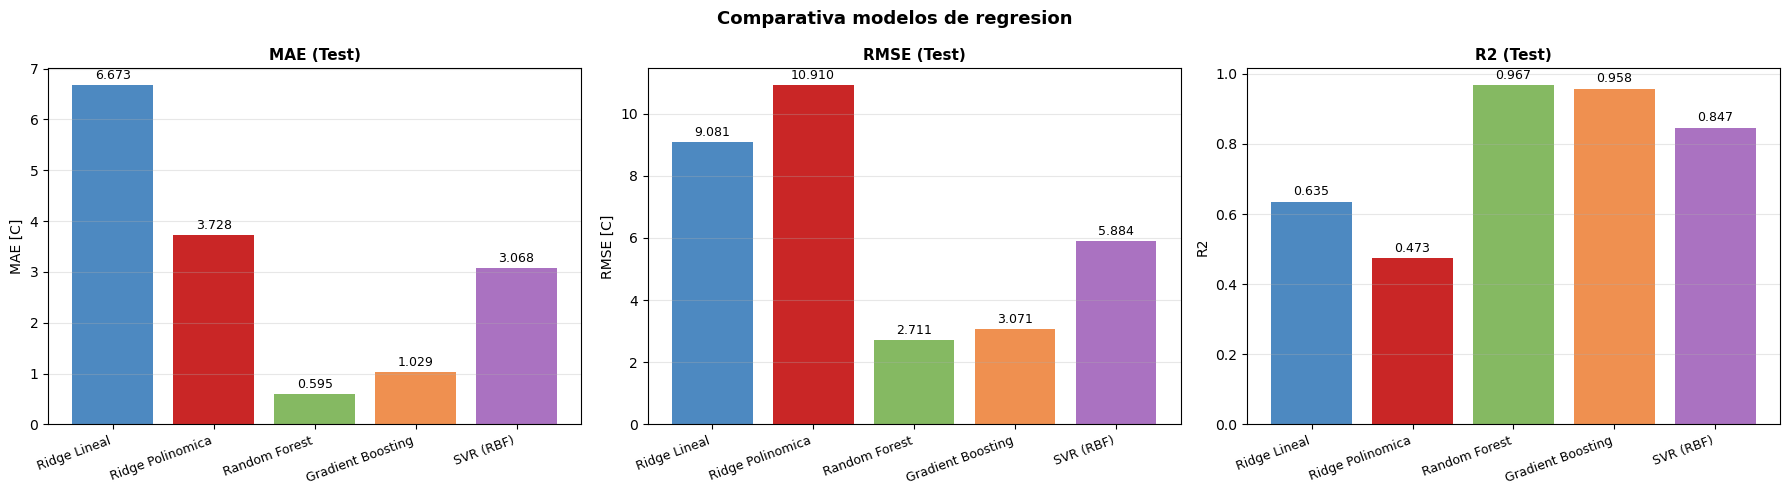

In [7]:
model_names = list(results.keys())
colors = ["#2E75B6", "#C00000", "#70AD47", "#ED7D31", "#9B59B6"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric, title, ylabel) in zip(axes, [
    ("test_mae",  "MAE (Test)",  "MAE [C]"),
    ("test_rmse", "RMSE (Test)", "RMSE [C]"),
    ("test_r2",   "R2 (Test)",   "R2"),
]):
    vals = [results[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors[:len(model_names)], alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Comparativa modelos de regresion", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("regresion_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

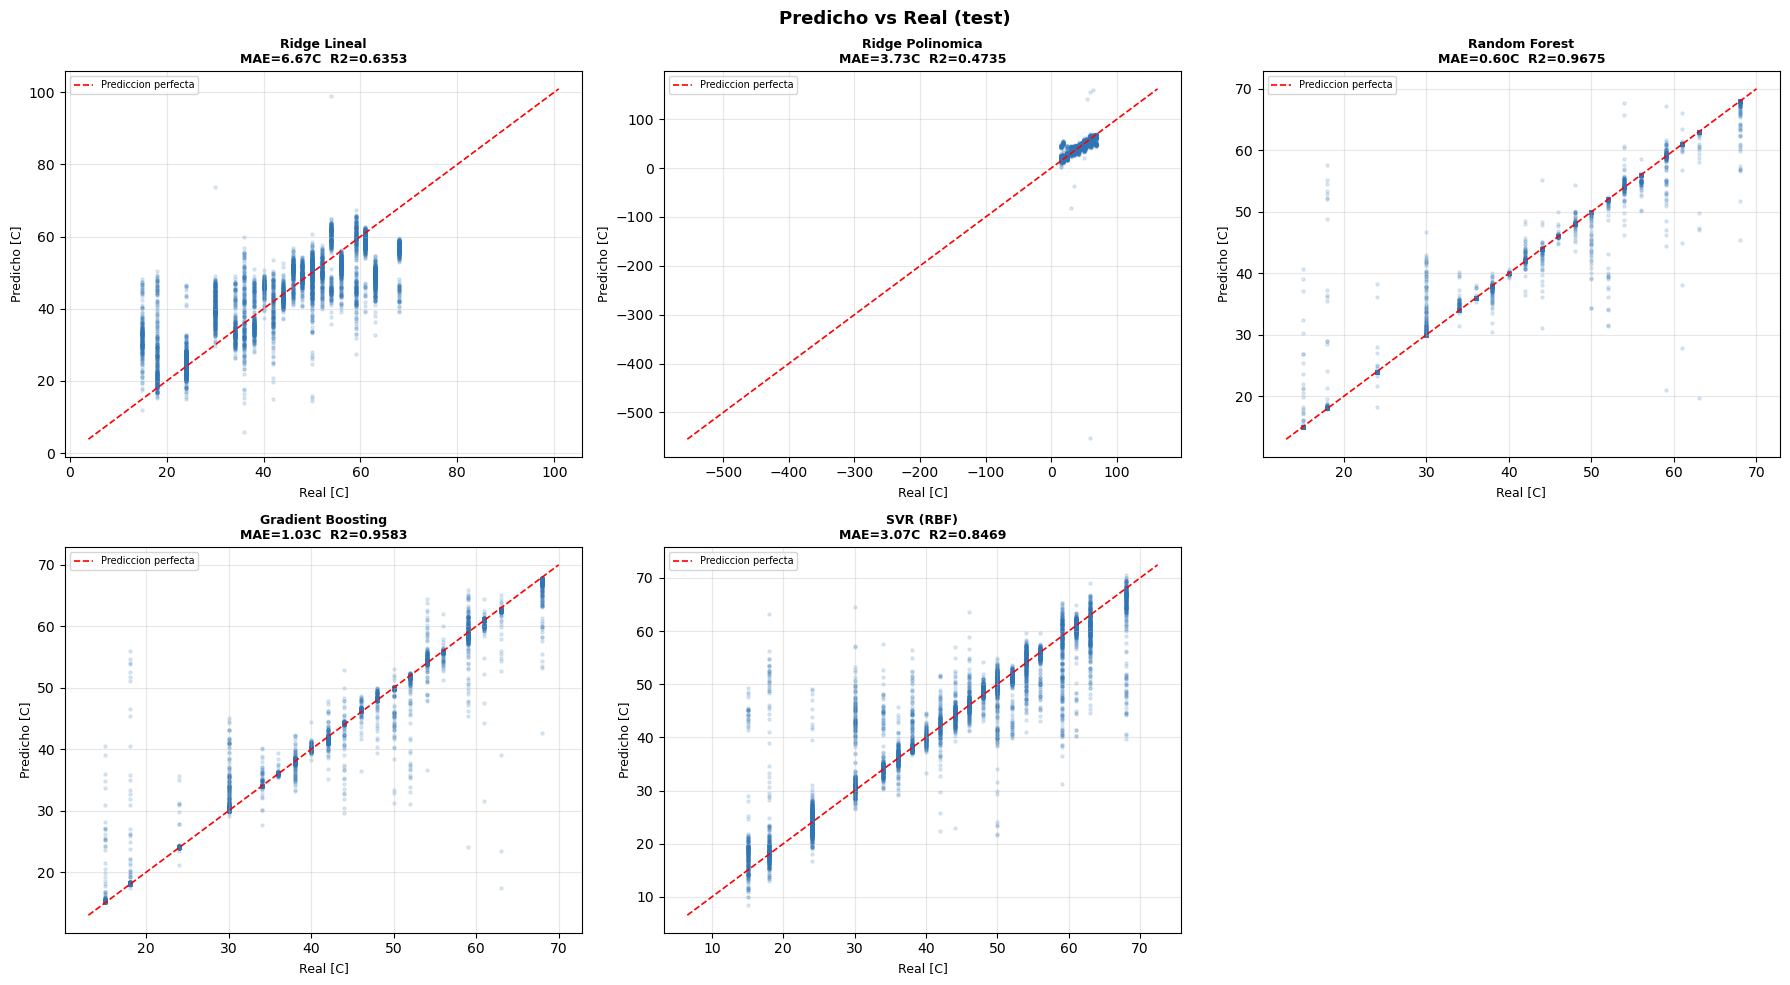

In [8]:
ncols = 3
nrows = (len(MODELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    ax = axes[i]
    preds = r["preds"]
    mae   = r["test_mae"]
    r2    = r["test_r2"]
    ax.scatter(y_test, preds, alpha=0.15, s=5, c="#2E75B6")
    lim = [min(y_test.min(), preds.min()) - 2,
           max(y_test.max(), preds.max()) + 2]
    ax.plot(lim, lim, "r--", linewidth=1.2, label="Prediccion perfecta")
    ax.set_xlabel("Real [C]", fontsize=9)
    ax.set_ylabel("Predicho [C]", fontsize=9)
    ax.set_title(f"{name}\nMAE={mae:.2f}C  R2={r2:.4f}",
                 fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Predicho vs Real (test)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("regresion_predicho_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

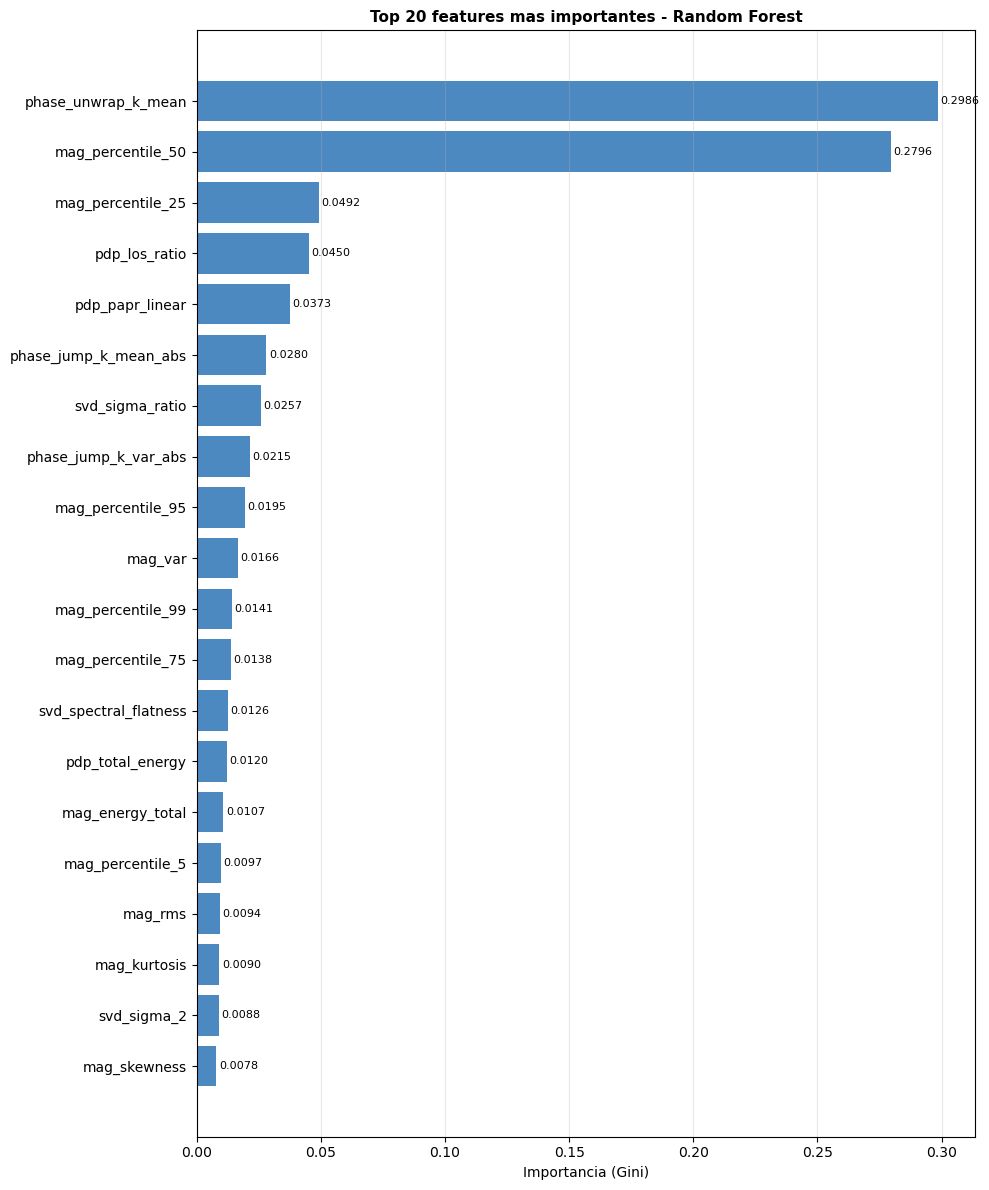

In [9]:
rf_step = MODELS["Random Forest"].named_steps["model"]
importances = pd.Series(
    rf_step.feature_importances_, index=FEAT_COLS
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
top20 = importances.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color="#2E75B6", alpha=0.85)
ax.set_xlabel("Importancia (Gini)", fontsize=10)
ax.set_title("Top 20 features mas importantes - Random Forest",
             fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
for i, (val, feat) in enumerate(zip(top20.values[::-1], top20.index[::-1])):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("regresion_importancia_rf.png", dpi=150, bbox_inches="tight")
plt.show()

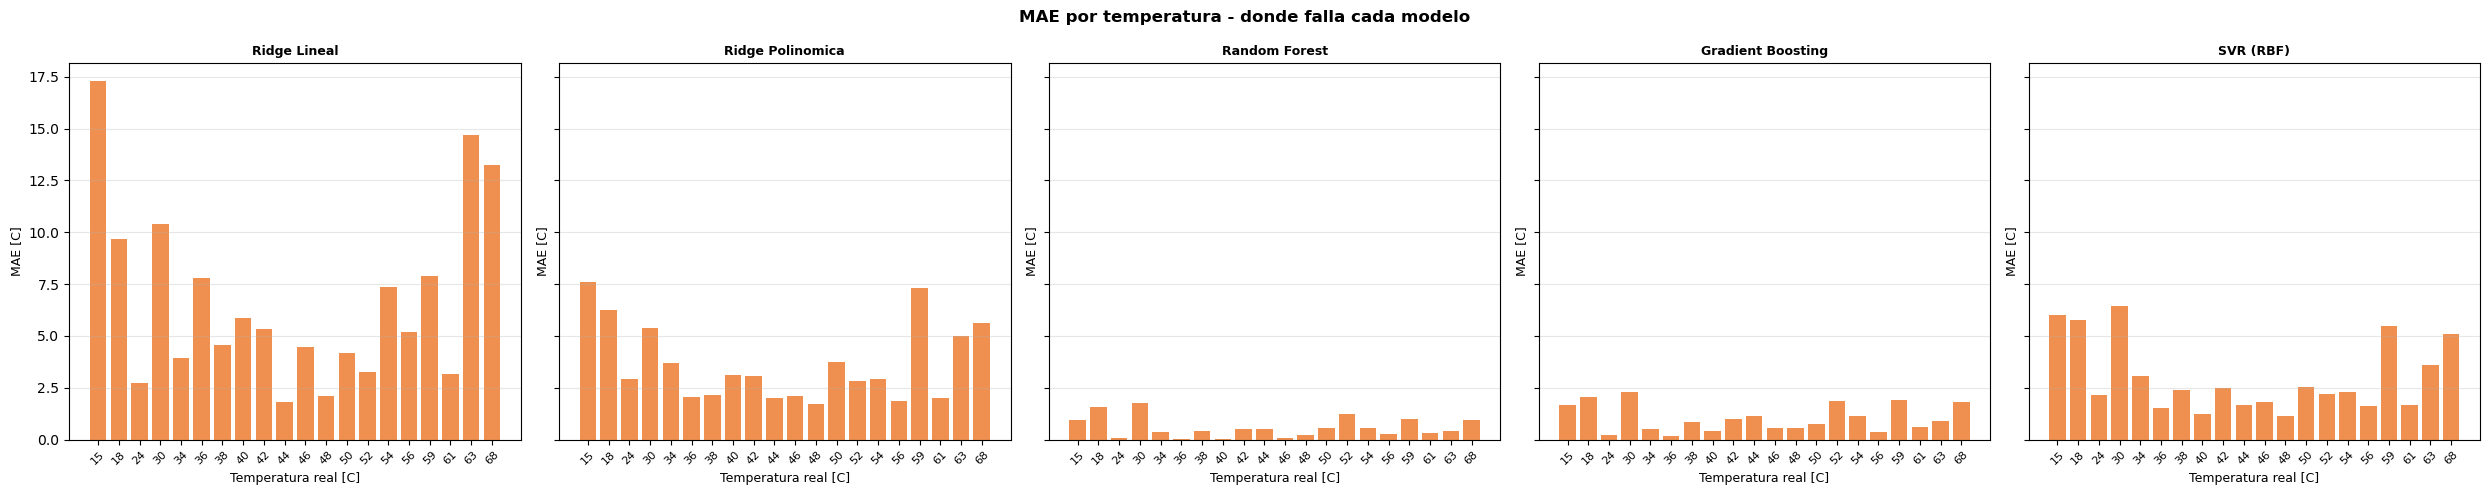

In [10]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 5), sharey=True)

for ax, (name, r) in zip(axes, results.items()):
    preds = r["preds"]
    mae_per_temp = {}
    for temp in sorted(df["temperature"].unique()):
        mask = y_test == temp
        if mask.sum() > 0:
            mae_per_temp[int(temp)] = mean_absolute_error(
                y_test[mask], preds[mask]
            )
    ax.bar([str(k) for k in mae_per_temp.keys()],
           list(mae_per_temp.values()),
           color="#ED7D31", alpha=0.85)
    ax.set_xlabel("Temperatura real [C]", fontsize=9)
    ax.set_ylabel("MAE [C]", fontsize=9)
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("MAE por temperatura - donde falla cada modelo",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("regresion_mae_por_temp.png", dpi=150, bbox_inches="tight")
plt.show()